# Arquitectura U-Net para segmentación

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Red neuronal

### Bloque convolucional

In [2]:
class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)

In [3]:
# Ejemplo de uso:

in_channels, out_channels = 3, 64
batch_size, height, width = 8, 256, 256

conv_block = ConvBlock(in_channels, out_channels)

x = torch.randn(batch_size, in_channels, height, width)
y = conv_block(x)

assert y.shape == (batch_size, out_channels, height, width)

### Bloque downsampling

In [4]:
class DownBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.down = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        skip = self.conv(x)
        output = self.down(skip)
        return output, skip

In [5]:
# Ejemplo de uso:

in_channels, out_channels = 32, 64
batch_size, height, width = 8, 256, 256

down_block = DownBlock(in_channels, out_channels)

x = torch.randn(batch_size, in_channels, height, width)
output, skip = down_block(x)

assert output.shape == (batch_size, out_channels, height // 2, width // 2)
assert skip.shape == (batch_size, out_channels, height, width)

### Bloque upsampling

In [6]:
class UpBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_channels, out_channels)

    def forward(self, x, skip):
       x = self.up(x)
       x = torch.cat([x, skip], dim=1)
       return self.conv(x)

In [7]:
# Ejemplo de uso:

in_channels, out_channels = 64, 32
batch_size, height, width = 8, 256, 256

up_block = UpBlock(in_channels, out_channels)

x = torch.randn(batch_size, in_channels, height, width)
skip = torch.randn(batch_size, in_channels // 2, 2*height, 2*width)
y = up_block(x, skip)

assert y.shape == (batch_size, out_channels, 2*height, 2*width)

### Arquitectura U-Net

In [8]:
class UNet(nn.Module):

    def __init__(self, in_channels, n_classes, base_ch=64):
        super().__init__()

        self.down1 = DownBlock(in_channels, base_ch)
        self.down2 = DownBlock(base_ch, base_ch*2)
        self.down3 = DownBlock(base_ch*2, base_ch*4)
        self.down4 = DownBlock(base_ch*4, base_ch*8)

        self.bottleneck = ConvBlock(base_ch*8, base_ch*16)

        self.up4 = UpBlock(base_ch*16, base_ch*8)
        self.up3 = UpBlock(base_ch*8, base_ch*4)
        self.up2 = UpBlock(base_ch*4, base_ch*2)
        self.up1 = UpBlock(base_ch*2, base_ch)

        self.out = nn.Conv2d(base_ch, n_classes, kernel_size=1)

    def forward(self, x):
        x, skip1 = self.down1(x)
        x, skip2 = self.down2(x)
        x, skip3 = self.down3(x)
        x, skip4 = self.down4(x)

        x = self.bottleneck(x)

        x = self.up4(x, skip4)
        x = self.up3(x, skip3)
        x = self.up2(x, skip2)
        x = self.up1(x, skip1)
        
        return self.out(x)

In [9]:
# Ejemplo de uso:

in_channels, n_classes = 3, 1
batch_size, height, width = 8, 256, 256

unet = UNet(in_channels, n_classes)

x = torch.randn(batch_size, in_channels, height, width)
y = unet(x)
assert y.shape == (batch_size, n_classes, height, width)

## Uso para segmentación de imágenes

### Datos de entrenamiento

In [10]:
img_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])

def transform(img, mask):
    img = img_transform(img)
    mask = mask_transform(mask).long().squeeze()
    return img, (mask - 1)

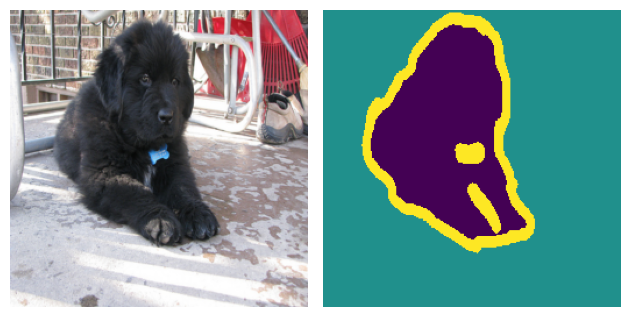

In [11]:
dataset = OxfordIIITPet(root='data', download=True, target_types='segmentation', transforms=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

# Ejemplo:
idx = torch.randint(len(dataset), [1]).item()
img, mask = dataset[idx]

plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.axis('off')

plt.tight_layout()
plt.show()

### Entrenamiento

In [12]:
def train(model, optimizer, dataloader, n_epochs):

    model.to(DEVICE)
    model.train()

    loss_fn = nn.CrossEntropyLoss()
    losses = []

    try:
        for epoch in range(n_epochs): 
            pbar = tqdm(dataloader, desc=f'Época {epoch+1}/{n_epochs}')
            for imgs, masks in pbar:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                logits = model(imgs)
                loss = loss_fn(logits, masks)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                pbar.set_postfix(loss=loss.item())
                losses.append(loss.item())

    except KeyboardInterrupt:
        print('Entrenamiento interrumpido.')
        training_log = {'model': model.state_dict(), 'losses': losses}
        torch.save(training_log, 'training.pt')

In [13]:
model = UNet(in_channels=3, n_classes=3)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

#train(model, optimizer, dataloader, n_epochs=50)

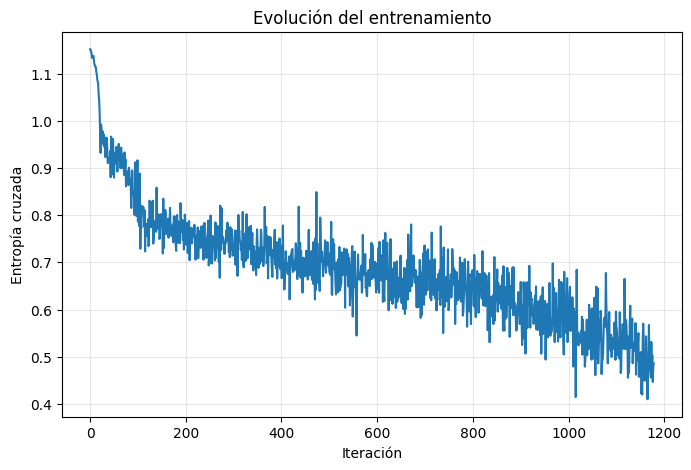

In [14]:
training_log = torch.load('training.pt', map_location=DEVICE, weights_only=True)
model.load_state_dict(training_log['model'])

# Dinámica entrenamiento:
plt.figure(figsize=(8, 5))
plt.plot(training_log['losses'])
plt.xlabel('Iteración')
plt.ylabel('Entropía cruzada')
plt.title('Evolución del entrenamiento')
plt.grid(alpha=0.3)
plt.show()

### Predicción

In [15]:
def predict_mask(model, img):
    model.eval()
    model.to(DEVICE)
    with torch.no_grad():
        img = img.unsqueeze(0).to(DEVICE)
        logits = model(img)
        probs = torch.softmax(logits, dim=1)
        pred_mask = torch.argmax(probs, dim=1)
    return pred_mask.squeeze().cpu()

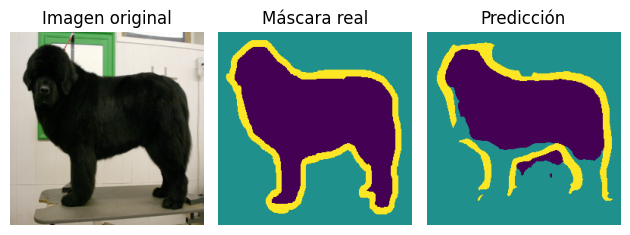

In [28]:
idx = torch.randint(len(dataset), [1]).item()
img, mask_true = dataset[idx]
mask_pred = predict_mask(model, img)

plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_true)
plt.title('Máscara real')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask_pred)
plt.title('Predicción')
plt.axis('off')

plt.tight_layout()
plt.show()